In [1]:
import numpy as np #numerical python
import matplotlib.pyplot as plt #for plotting
from matplotlib.cm import get_cmap #import colour maps for contour plots
import netCDF4
from netCDF4 import Dataset, date2num #for reading netCDF data files and their date (not sure if I need the later)
import time #for timing how long a computation takes
import shapefile as shp # to import outline of GTA
from shapely import geometry # used to define boundaries of TROPOMI pixels
import geopandas
import pandas as pd

In [2]:
sf = shp.Reader("C:/Users/kitty/Documents/Research/SIF/Shape_files/Toronto/Toronto_Boundary.shp")
#Toronto_Shape
shape=sf.shape(0)
#Need to partition each individual shape
Toronto_x = np.zeros((len(shape.points),1))*np.nan #The main portion of the GTA
Toronto_y = np.zeros((len(shape.points),1))*np.nan
for i in range(len(shape.points)):
    Toronto_x[i]=shape.points[i][0]
    Toronto_y[i]=shape.points[i][1]

In [5]:
points=[geometry.Point(Toronto_x[i],Toronto_y[i]) for i in range(len(Toronto_x))] 
poly=geometry.Polygon([[p.x, p.y,0] for p in points])

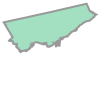

In [6]:
poly

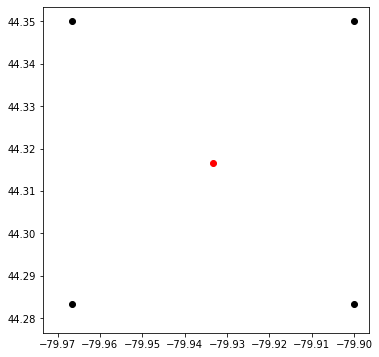

In [2]:
step=500*180/(6.378*10**6*np.pi)
plt.figure(figsize=(12,6))
plt.xlim([-79.97,-79.90])
plt.ylim([44.28,44.35]) 
plt.axis('scaled')
plt.scatter(-79.9333,44.3166700,color='r') #Borden forest Research Center is located at 44.3166700, -79.9333
plt.scatter(-79.9333+8/240,44.3166700+8/240,color='k') #Borden forest Research Center is located at 44.3166700, -79.9333
plt.scatter(-79.9333-8/240,44.3166700+8/240,color='k') #Borden forest Research Center is located at 44.3166700, -79.9333
plt.scatter(-79.9333+8/240,44.3166700-8/240,color='k') #Borden forest Research Center is located at 44.3166700, -79.9333
plt.scatter(-79.9333-8/240,44.3166700-8/240,color='k') #Borden forest Research Center is located at 44.3166700, -79.9333
plt.show()

In [3]:
lob=[-79.9333-8/240,-79.9333+8/240,-79.9333+8/240,-79.9333-8/240]
lab=[44.3166700+8/240,44.3166700+8/240,44.3166700-8/240,44.3166700-8/240]

In [4]:
points=[geometry.Point(lob[0],lab[0]),geometry.Point(lob[1],lab[1]),geometry.Point(lob[2],lab[2]),geometry.Point(lob[3],lab[3]),geometry.Point(lob[0],lab[0])]
poly=geometry.Polygon([[p.x, p.y,0] for p in points])

In [7]:
GTA_df=pd.DataFrame({'Name':['GTA_30m_BB'], 'descriptio':[None], 'timestamp':[None], 'begin':[None], 'end':[None], 'altitudeMo':[None], 'tesselate':[1], 'extrude':[0], 'visibility':[-1], 'drawOrder':[None], 'icon':[None]})

In [8]:
GTA_gdf=geopandas.GeoDataFrame(GTA_df, geometry=geopandas.GeoSeries(poly,crs='+proj=longlat +datum=WGS84 +no_defs'))
GTA_gdf

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,GTA_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-79.33131 43.62580 0.00000, -79.33..."


In [10]:
GTA_gdf.crs

'+proj=longlat +datum=WGS84 +no_defs'

In [14]:
GTA_gdf.to_file('C:/Users/kitty/Documents/Research/SIF/Shape_files/Toronto/Toronto_BB.shp')

In [15]:
GTA_test=geopandas.read_file('C:/Users/kitty/Documents/Research/SIF/Shape_files/Toronto/Toronto_BB.shp')
GTA_test

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,GTA_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-79.33131 43.62580 0.00000, -79.33..."


In [24]:
NIST_test=geopandas.read_file("C:/Users/kitty/Documents/Research/SIF/UrbanVPRM/UrbanVPRM/dataverse_files/NIST30/shapefiles/NIST_30m_BB.shp",fields=['end'],)

In [25]:
NIST_test

,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,icon,geometry
0,NIST_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-77.24139 39.13911 0.00000, -77.20..."


In [26]:
NIST_test ['geometry']

0    POLYGON Z ((-77.24139 39.13911 0.00000, -77.20...
Name: geometry, dtype: geometry

In [27]:
NIST_test.geometry

0    POLYGON Z ((-77.24139 39.13911 0.00000, -77.20...
Name: geometry, dtype: geometry

In [5]:
Borden_df=pd.DataFrame({'Name':['Borden_30m_BB'], 'descriptio':[None], 'timestamp':[None], 'begin':[None], 'end':[None], 'altitudeMo':[None], 'tesselate':[1], 'extrude':[0], 'visibility':[-1], 'drawOrder':[None], 'icon':[None]})

In [6]:
Borden_df

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon
0,Borden_30m_BB,None,None,None,None,None,1,0,-1,None,None


In [7]:
geopandas.GeoSeries(poly)

0    POLYGON Z ((-79.96663 44.35000 0.00000, -79.89...
dtype: geometry

In [8]:
Borden_gdf=geopandas.GeoDataFrame(Borden_df, geometry=geopandas.GeoSeries(poly,crs='+proj=longlat +datum=WGS84 +no_defs'))

In [9]:
Borden_gdf

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,Borden_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-79.96663 44.35000 0.00000, -79.89..."


In [11]:
Borden_gdf.to_file('Borden_30m_BB_4km.shp')

In [12]:
Borden_test=geopandas.read_file("C:/Users/kitty/Documents/Research/SIF/UrbanVPRM/UrbanVPRM/dataverse_files/Borden/shapefiles/Borden_30m_BB_4km.shp")

In [13]:
Borden_test

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,Borden_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-79.96663 44.35000 0.00000, -79.89..."


In [14]:
Borden_test.crs

{'init': 'epsg:4326'}

In [3]:
# Do the same for TP39

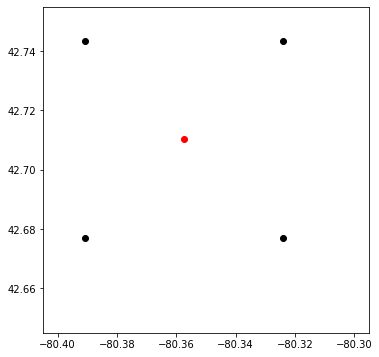

In [2]:
step=500*180/(6.378*10**6*np.pi)
plt.figure(figsize=(12,6))
plt.xlim([-80.4,-80.3])
plt.ylim([42.65,42.75]) 
plt.axis('scaled')
plt.scatter(-80.3574, 42.7102, color='r') #TP39 Research Center
plt.scatter(-80.3574+8/240, 42.7102+8/240, color='k')
plt.scatter(-80.3574-8/240, 42.7102+8/240, color='k')
plt.scatter(-80.3574+8/240, 42.7102-8/240, color='k')
plt.scatter(-80.3574-8/240, 42.7102-8/240, color='k')
plt.show()

In [3]:
lob=[-80.3574-8/240,-80.3574+8/240,-80.3574+8/240,-80.3574-8/240]
lab=[42.7102+8/240,42.7102+8/240,42.7102-8/240,42.7102-8/240]

In [4]:
points=[geometry.Point(lob[0],lab[0]),geometry.Point(lob[1],lab[1]),geometry.Point(lob[2],lab[2]),geometry.Point(lob[3],lab[3]),geometry.Point(lob[0],lab[0])]
poly=geometry.Polygon([[p.x, p.y,0] for p in points])

In [5]:
TP39_df=pd.DataFrame({'Name':['TP39_30m_BB'], 'descriptio':[None], 'timestamp':[None], 'begin':[None], 'end':[None], 'altitudeMo':[None], 'tesselate':[1], 'extrude':[0], 'visibility':[-1], 'drawOrder':[None], 'icon':[None]})

In [6]:
geopandas.GeoSeries(poly)

0    POLYGON Z ((-80.39073 42.74353 0.00000, -80.32...
dtype: geometry

In [7]:
TP39_gdf=geopandas.GeoDataFrame(TP39_df, geometry=geopandas.GeoSeries(poly,crs='+proj=longlat +datum=WGS84 +no_defs'))
TP39_gdf

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,TP39_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-80.39073 42.74353 0.00000, -80.32..."


In [8]:
TP39_gdf.crs

'+proj=longlat +datum=WGS84 +no_defs'

In [9]:
TP39_gdf.to_file('C:/Users/kitty/Documents/Research/SIF/UrbanVPRM/UrbanVPRM/dataverse_files/TP39/shapefiles/TP39_30m_BB_4km.shp')

In [10]:
TP39_test=geopandas.read_file("C:/Users/kitty/Documents/Research/SIF/UrbanVPRM/UrbanVPRM/dataverse_files/TP39/shapefiles/TP39_30m_BB_4km.shp")
TP39_test

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,TP39_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-80.39073 42.74353 0.00000, -80.32..."


In [11]:
TP39_test.crs

{'init': 'epsg:4326'}

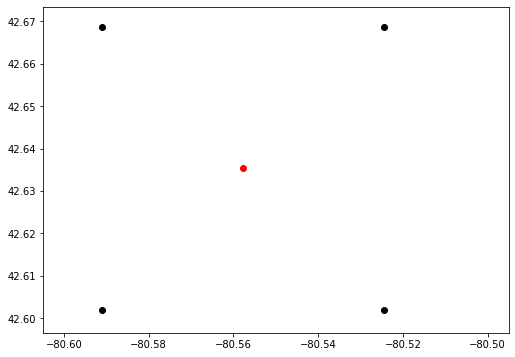

In [12]:
#Do the same for TPD
step=500*180/(6.378*10**6*np.pi)
plt.figure(figsize=(12,6))
plt.xlim([-80.6,-80.5])
plt.ylim([42.6,42.67]) 
plt.axis('scaled')
plt.scatter(-80.5577, 42.6353, color='r') #TP39 Research Center
plt.scatter(-80.5577+8/240, 42.6353+8/240, color='k') 
plt.scatter(-80.5577-8/240, 42.6353+8/240, color='k') 
plt.scatter(-80.5577-8/240, 42.6353-8/240, color='k') 
plt.scatter(-80.5577+8/240, 42.6353-8/240, color='k') 
plt.show()

In [13]:
lob=[-80.5577-8/240,-80.5577+8/240,-80.5577+8/240,-80.5577-8/240]
lab=[42.6353+8/240,42.6353+8/240,42.6353-8/240,42.6353-8/240]
points=[geometry.Point(lob[0],lab[0]),geometry.Point(lob[1],lab[1]),geometry.Point(lob[2],lab[2]),geometry.Point(lob[3],lab[3]),geometry.Point(lob[0],lab[0])]
poly=geometry.Polygon([[p.x, p.y,0] for p in points])

In [14]:
TPD_df=pd.DataFrame({'Name':['TPD_30m_BB'], 'descriptio':[None], 'timestamp':[None], 'begin':[None], 'end':[None], 'altitudeMo':[None], 'tesselate':[1], 'extrude':[0], 'visibility':[-1], 'drawOrder':[None], 'icon':[None]})

In [15]:
TPD_gdf=geopandas.GeoDataFrame(TPD_df, geometry=geopandas.GeoSeries(poly,crs='+proj=longlat +datum=WGS84 +no_defs'))
TPD_gdf

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,TPD_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-80.59103 42.66863 0.00000, -80.52..."


In [16]:
TPD_gdf.crs

'+proj=longlat +datum=WGS84 +no_defs'

In [17]:
TPD_gdf.to_file('C:/Users/kitty/Documents/Research/SIF/UrbanVPRM/UrbanVPRM/dataverse_files/TPD/shapefiles/TPD_30m_BB_4km.shp')

In [18]:
TPD_test=geopandas.read_file("C:/Users/kitty/Documents/Research/SIF/UrbanVPRM/UrbanVPRM/dataverse_files/TPD/shapefiles/TPD_30m_BB_4km.shp")
TPD_test

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,TPD_30m_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-80.59103 42.66863 0.00000, -80.52..."


In [19]:
TPD_test.crs

{'init': 'epsg:4326'}

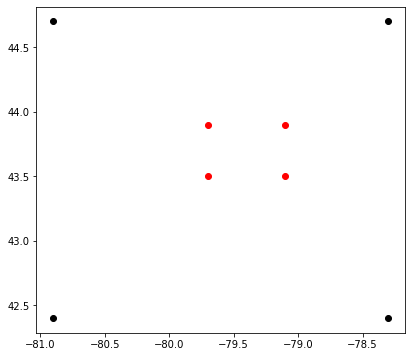

In [2]:
#Do the same for area covering Toronto
step=500*180/(6.378*10**6*np.pi)
plt.figure(figsize=(12,6))
plt.xlim([-80.9,-78.3])
plt.ylim([42.4,44.7]) 
plt.axis('scaled')
plt.scatter(-80.9, 44.7, color='k') 
plt.scatter(-78.3, 44.7, color='k') 
plt.scatter(-78.3, 42.4, color='k') 
plt.scatter(-80.9, 42.4, color='k')
plt.scatter(-79.7, 43.9, color='r')
plt.scatter(-79.1, 43.9, color='r')
plt.scatter(-79.1, 43.5, color='r')
plt.scatter(-79.7, 43.5, color='r')
plt.show()

In [12]:
lob=[-79.1,-79.7,-79.7,-79.1]
lab=[43.9,43.9,43.5,43.5]
points=[geometry.Point(lob[0],lab[0]),geometry.Point(lob[1],lab[1]),geometry.Point(lob[2],lab[2]),geometry.Point(lob[3],lab[3]),geometry.Point(lob[0],lab[0])]
poly=geometry.Polygon([[p.x, p.y,0] for p in points])

In [13]:
Toronto_df=pd.DataFrame({'Name':['GTA_BB'], 'descriptio':[None], 'timestamp':[None], 'begin':[None], 'end':[None], 'altitudeMo':[None], 'tesselate':[1], 'extrude':[0], 'visibility':[-1], 'drawOrder':[None], 'icon':[None]})
Toronto_gdf=geopandas.GeoDataFrame(Toronto_df, geometry=geopandas.GeoSeries(poly,crs='+proj=longlat +datum=WGS84 +no_defs'))
Toronto_gdf

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,GTA_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-79.10000 43.90000 0.00000, -79.70..."


In [15]:
Toronto_gdf.to_file('C:/Users/kitty/Documents/Research/SIF/UrbanVPRM/UrbanVPRM/dataverse_files/GTA_500m/shapefiles/GTA_500m_BB.shp')

In [16]:
Toronto_test=geopandas.read_file("C:/Users/kitty/Documents/Research/SIF/UrbanVPRM/UrbanVPRM/dataverse_files/GTA_500m/shapefiles/GTA_500m_BB.shp")
Toronto_test

,Name,descriptio,timestamp,begin,end,altitudeMo,tesselate,extrude,visibility,drawOrder,icon,geometry
0,GTA_BB,None,None,None,None,None,1,0,-1,None,None,"POLYGON Z ((-79.10000 43.90000 0.00000, -79.10..."
